In [ ]:
# Credit Card Fraud Detection Dataset (Kaggle ULB)
#A data set was collected and analyzed by European cardholders in September 2013. 
#It contains transactions made by credit cards in September 2013 by European cardholders. 
#This dataset presents transactions that occurred in two days, where we have 492 frauds 
#out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) 
#account for 0.172% of all transactions. It contains only numerical input variables which 
#are the result of a PCA transformation. Unfortunately, due to confidentiality issues, we 
#cannot provide the original features and more background information about the data. 
#Features V1, V2, ... V28 are the principal components obtained with PCA, the only features 
#which have not been transformed with PCA are 'Time' and 'Amount'. Feature 'Time' contains 
#the seconds elapsed between each transaction and the first transaction in the dataset. The 
#feature 'Amount' is the transaction Amount, this feature can be used for example-dependant 
#cost-sensitive learning. Feature 'Class' is the response variable and it takes value 1 in 
case of fraud and 0 otherwise.

In [ ]:
## Understanding the DataSet
#Firstly, I need to import my necessary library 
#After that, i'd need to get more info about the DataSet


In [1]:
import pandas as pd
df = pd.read_csv(r"D:\Users\Downloads\archive\creditcard.csv")
df.shape

(284807, 31)

In [2]:
# Now we will check the info of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [3]:
# Now we will check for the null values in the dataset
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [4]:
#Now we know that there are no null values in the dataset. Now we will check the distribution 
# of the target variable 'Class'
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

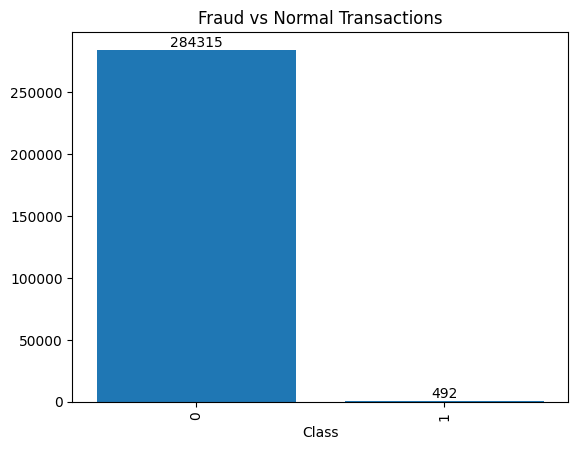

In [5]:
import matplotlib.pyplot as plt

df['Class'].value_counts().plot(kind='bar')
plt.title("Fraud vs Normal Transactions")
plt.bar_label(plt.bar(df['Class'].value_counts().index, df['Class'].value_counts().values))
plt.show()

In [6]:
# With the result above, we can see that the data is highly imbalanced. We will need to split the
# data into training and testing sets before we can apply any resampling techniques to balance 
# the data.
X = df.drop('Class', axis=1)
y = df['Class']

In [7]:
# we need to train the data with 80% of the data and test the data with 20% of the data. 
# We will use the train_test_split function from the sklearn library to split the data.
# while also use random state 42 to ensure that the results are reproducible Finally, I will also
# Stratify the data to ensure that the distribution of the target variable is the same in both the
# training and testing sets.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
# Now we need to put all features on the same scale. We will use the StandardScaler from the 
# sklearn library to avoid any bias in the model towards larger amounts.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Because the data is highly imbalanced, we will use the SMOTE technique to balance the data. 
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)  
x_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    solver='saga',
    max_iter=1000
)

model.fit(x_resampled, y_resampled)